# 📊 Análisis Exploratorio de Datos (EDA) Completo - SaleSight
Este notebook realiza el proceso EDA en la transformación de datos de SaleSight

In [ ]:
# Librerías y módulos para el EDA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sys
import os
from salesight.dataset import obtener_datos_db
from salesight.config import NOMBRE_DB

In [ ]:
# Configuración para importar el módulo del proyecto desde la subcarpeta notebooks
sys.path.append(os.path.abspath('..'))

# Configuración visual global
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.autolayout'] = True

## 1. Carga de Datos desde la Base de Datos
Se utiliza la capa de datos centralizada para asegurar que las fechas y tipos sean correctos.

In [16]:
df = obtener_datos_db(NOMBRE_DB)

if isinstance(df, pd.DataFrame):
    print(f"DataFrame cargado exitosamente. Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
    display(df.head())
else:
    print("Error: No se pudo cargar la base de datos. Asegúrate de haber ejecutado el pipeline de carga.")

2026-03-07 20:07:46.393 | INFO     | salesight.dataset:obtener_datos_db:18 - Conectando con la base de datos en: /Users/josue/Documents/Escritorio/Universidad/ingenieria_de_datos/corte_1/Proyecto/SaleSight/data/processed/ventas_procesadas.db 🔎
✅ DataFrame cargado exitosamente. Filas: 301651, Columnas: 31


,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,Age,Gender,Income,Customer_Segment,Order Date,Year,Month,Time,Quantity Ordered,Price Each,Sales,Product_Category,Product_Brand,Product,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products,Date
0,8691788.0,37249.0,Michelle Harrington,Ebony39@gmail.com,1.414787e+09,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,21.0,Male,Low,Regular,2023-09-18,2023.0,September,22:03:55,3.0,108.028757,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts,2023-09-18
1,2174773.0,69749.0,Kelsey Hill,Mark36@gmail.com,6.852900e+09,82072 Dawn Centers,Nottingham,England,99071.0,UK,19.0,Female,Low,Premium,2023-12-31,2023.0,December,8:42:04,2.0,403.353907,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab,2023-12-31
2,6679610.0,30192.0,Scott Jensen,Shane85@gmail.com,8.362160e+09,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,48.0,Male,Low,Regular,2023-04-26,2023.0,April,4:06:29,3.0,354.477600,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment,2023-04-26
3,7232460.0,62101.0,Joseph Miller,Mary34@gmail.com,2.776752e+09,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,56.0,Male,High,Premium,2023-05-08,2023.0,May,14:55:17,7.0,352.407717,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife,2023-05-08
4,4983775.0,27901.0,Debra Coleman,Charles30@gmail.com,9.098268e+09,5813 Lori Ports Suite 269,Bristol,England,48704.0,UK,22.0,Male,Low,Premium,2024-01-10,2024.0,January,16:54:07,2.0,124.276524,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies,2024-01-10


## 2. Estadísticos y Formato
Se define el formateador de moneda que se aplicará a todos los gráficos.

In [17]:
def formato_moneda(x, pos):
    if x >= 1_000_000:
        return f'${x*1e-6:1.1f}M'
    return f'${x:,.0f}'

formateador = ticker.FuncFormatter(formato_moneda)
display(df.describe())

,Transaction_ID,Customer_ID,Phone,Zipcode,Age,Order Date,Year,Quantity Ordered,Price Each,Sales,Ratings
count,3.013180e+05,301343.000000,3.012890e+05,301312.000000,301479.000000,301651,301301.000000,301651.000000,301651.000000,301651.000000,301467.000000
mean,5.495772e+06,55010.219331,5.501353e+09,50299.478424,35.482899,2023-08-30 16:17:07.497340,2023.165121,5.359574,255.176374,1367.387659,3.162565
min,1.000007e+06,10000.000000,1.000049e+09,501.000000,18.000000,2023-03-01 00:00:00,2023.000000,1.000000,10.000219,10.003750,1.000000
25%,3.247782e+06,32472.500000,3.255178e+09,25426.000000,22.000000,2023-05-31 00:00:00,2023.000000,3.000000,133.048704,439.356827,2.000000
50%,5.499516e+06,55016.000000,5.505629e+09,50605.000000,32.000000,2023-08-31 00:00:00,2023.000000,5.000000,255.456747,1041.318069,3.000000
75%,7.739532e+06,77512.000000,7.749691e+09,75250.250000,46.000000,2023-11-30 00:00:00,2023.000000,8.000000,377.505128,2028.169971,4.000000
max,9.999995e+06,99999.000000,9.999996e+09,99949.000000,70.000000,2024-02-29 00:00:00,2024.000000,10.000000,499.997911,4999.625796,5.000000
std,2.595689e+06,26005.504140,2.595924e+09,28972.339698,15.023087,NaN,0.371290,2.866719,141.302824,1128.346404,1.320820


## 3. Visualizaciones (Misma lógica que plots.py)

### 3.1 Ingresos Totales por Categoría
Se analiza qué productos generan mayor facturación.

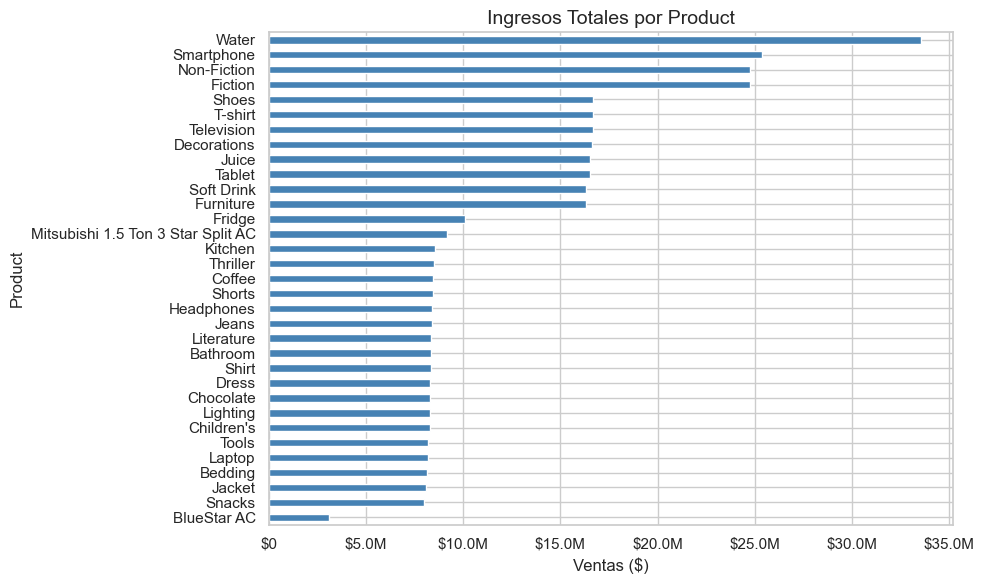

In [18]:
# Devolver la columna categoria si existe en el dataframe
col_cat = 'Product' if 'Product' in df.columns else 'Product_Category'

# Se define el tamaño del canvas y las ventas por categoría
plt.figure(figsize=(10, 6))
ventas_cat = df.groupby(col_cat)['Sales'].sum().sort_values(ascending=True)

# Definir el gráfico como de barras de color azul
ax = ventas_cat.plot(kind='barh', color='steelblue')
ax.xaxis.set_major_formatter(formateador)

# Características del gráfico
plt.title(f'Ingresos Totales por {col_cat}', fontsize=14)
plt.xlabel('Ventas ($)')
plt.ylabel(col_cat)

# mostrar el gráfico
plt.show()

### 3.2 Perfil del Cliente: Ingresos y Género
Se visualiza el volumen de clientes por nivel socioeconómico y sexo.

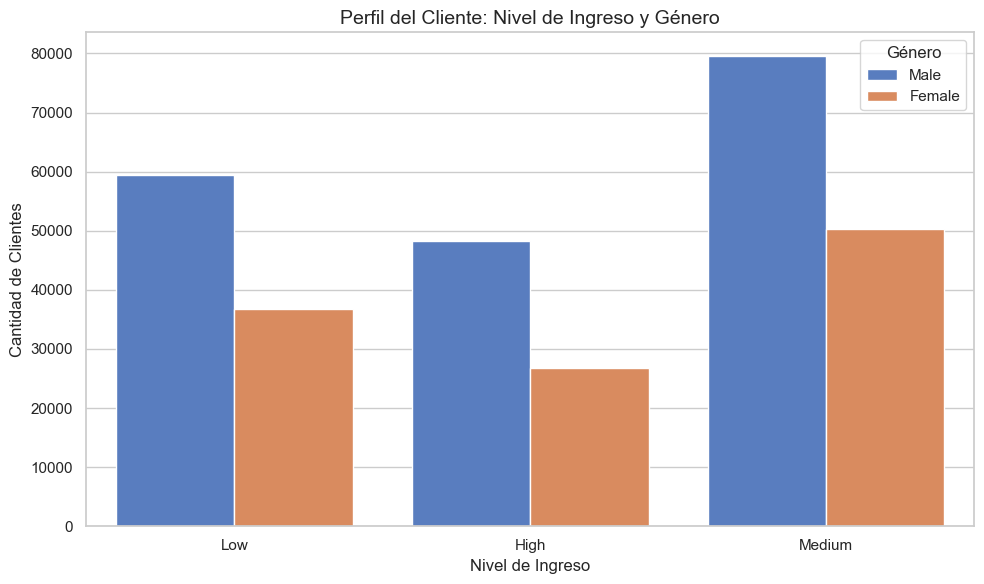

In [19]:
# Gráfico de relación entre ingresos y género
if 'Income' in df.columns and 'Gender' in df.columns:

    # Creación del gráfico de conteo
    plt.figure(figsize=(10, 6))
    sns.countplot(x='Income', hue='Gender', data=df, palette='muted')

    # Características del gráfico
    plt.title('Perfil del Cliente: Nivel de Ingreso y Género', fontsize=14)
    plt.xlabel('Nivel de Ingreso')
    plt.ylabel('Cantidad de Clientes')
    plt.legend(title='Género')

    # Mostrar el gráfico
    plt.show()

### 3.3 Preferencia de Métodos de Pago
Distribución porcentual de los medios de pago utilizados.

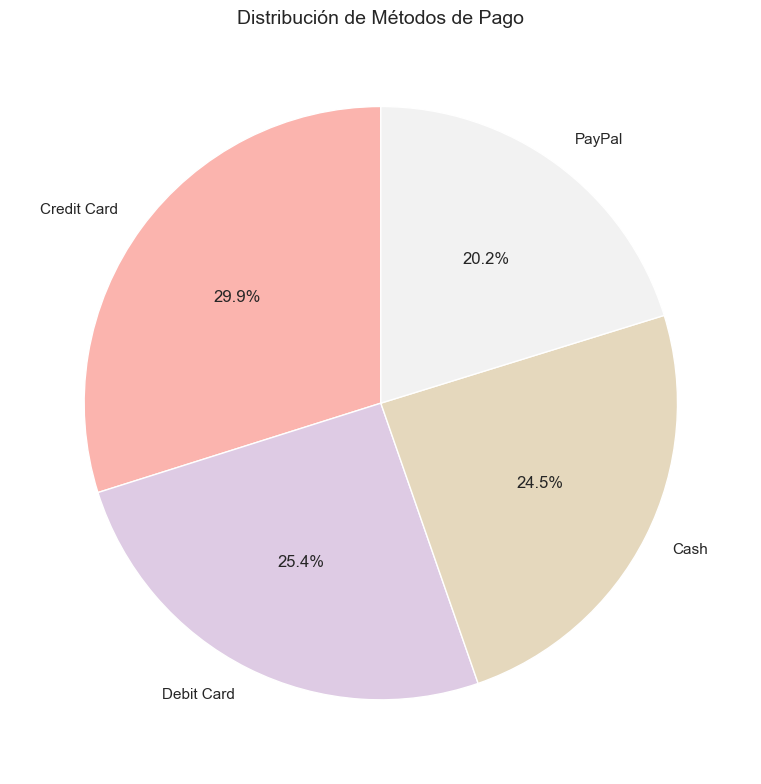

In [20]:
# Creación de un gráfico de torta sobre la distribución de métodos de pago preferidos
if 'Payment_Method' in df.columns:
    # Características del gráfico
    plt.figure(figsize=(8, 8))
    df['Payment_Method'].value_counts().plot(kind='pie', autopct='%1.1f%%', colormap='Pastel1', startangle=90)
    plt.title('Distribución de Métodos de Pago', fontsize=14)
    plt.ylabel('')

    # Mostrar el gráfico
    plt.show()

### 3.4 Tendencia Histórica Mensual
Visualización de la evolución de ingresos con orden cronológico de meses.

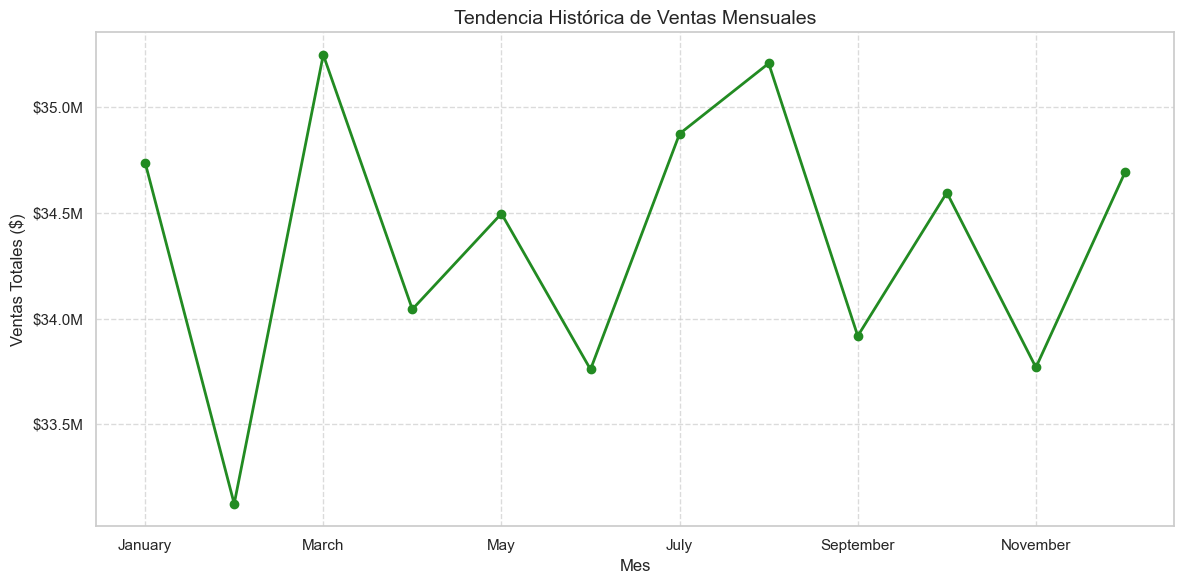

In [21]:
# Gráfico de tendencia histórica
if 'Order Date' in df.columns and 'Sales' in df.columns:
    df_trend = df.copy()
    # Asegurar orden cronológico de los meses
    df_trend['Month_Name'] = df_trend['Order Date'].dt.month_name()
    orden_meses = ['January', 'February', 'March', 'April', 'May', 'June', 
                   'July', 'August', 'September', 'October', 'November', 'December']
    df_trend['Month_Name'] = pd.Categorical(df_trend['Month_Name'], categories=orden_meses, ordered=True)
    
    # Características del gráfico
    plt.figure(figsize=(12, 6))
    tendencia = df_trend.groupby('Month_Name', observed=True)['Sales'].sum()
    ax = tendencia.plot(kind='line', marker='o', color='forestgreen', linewidth=2)
    ax.yaxis.set_major_formatter(formateador)
    plt.title('Tendencia Histórica de Ventas Mensuales', fontsize=14)
    plt.xlabel('Mes')
    plt.ylabel('Ventas Totales ($)')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Mostrar el gráfico
    plt.show()

### 3.5 Top 5 Países con Mayor Facturación
Ranking de los mercados internacionales más importantes.

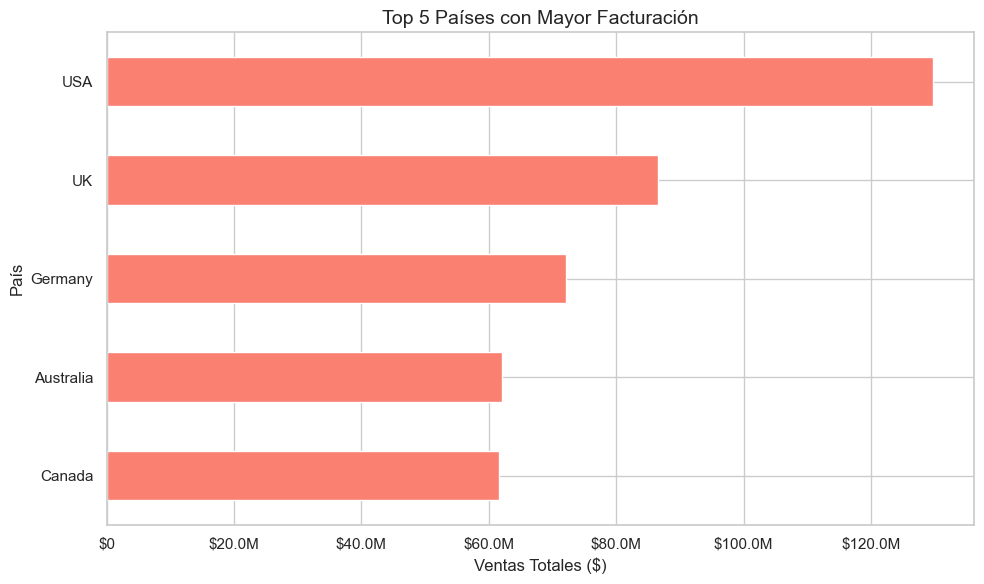

In [23]:
# Gráfico de paises con mayor facturación
if 'Country' in df.columns and 'Sales' in df.columns:
    # Características del gráfico
    plt.figure(figsize=(10, 6))
    paises = df.groupby('Country')['Sales'].sum().nlargest(5).sort_values(ascending=True)
    ax = paises.plot(kind='barh', color='salmon')
    ax.xaxis.set_major_formatter(formateador)
    plt.title('Top 5 Países con Mayor Facturación', fontsize=14)
    plt.xlabel('Ventas Totales ($)')
    plt.ylabel('País')

    # Mostrar el gráfico
    plt.show()